#📌 Extracción

In [10]:
import requests
import pandas as pd

# Define la URL de la API de Telecom X
# ¡IMPORTANTE! Reemplaza esta URL con la URL real de la API.
api_url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json'

try:
    # Realiza la solicitud GET a la API
    response = requests.get(api_url)

    # Verifica que la solicitud fue exitosa (código de estado 200)
    response.raise_for_status()

    # Parsea la respuesta JSON
    data = response.json()

    # Convierte los datos JSON en un DataFrame de pandas
    df_clientes = pd.DataFrame(data)

    print("Datos extraídos con éxito de la API y cargados en 'df_clientes'.")
    print(f"Número de registros: {len(df_clientes)}")
    print("Primeras 5 filas del DataFrame:")
    print(df_clientes.head())

except requests.exceptions.RequestException as e:
    print(f"Error al conectar o recibir datos de la API: {e}")
except ValueError as e:
    print(f"Error al decodificar la respuesta JSON: {e}")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Datos extraídos con éxito de la API y cargados en 'df_clientes'.
Número de registros: 7267
Primeras 5 filas del DataFrame:
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '..

#🔧 Transformación

In [11]:
print(df_clientes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB
None


#📊 Carga y análisis

In [12]:
import numpy as np

# Aplanar la columna 'customer'
for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents']:
    df_clientes[col] = df_clientes['customer'].apply(lambda x: x.get(col))

# Aplanar la columna 'phone'
for col in ['PhoneService', 'MultipleLines']:
    df_clientes[col] = df_clientes['phone'].apply(lambda x: x.get(col))

# Aplanar la columna 'internet'
for col in ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df_clientes[col] = df_clientes['internet'].apply(lambda x: x.get(col))

# Aplanar la columna 'account'
for col in ['Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure']:
    df_clientes[col] = df_clientes['account'].apply(lambda x: x.get(col))

# Eliminar las columnas anidadas originales después de aplanarlas
df_clientes = df_clientes.drop(columns=['customer', 'phone', 'internet', 'account'])

print("Columnas anidadas aplanadas con éxito.")
print("Primeras 5 filas del DataFrame con las nuevas columnas:")
print(df_clientes.head())

# Ahora que las columnas están aplanadas, revisemos los valores ausentes en el DataFrame completo
missing_values = df_clientes.isnull().sum()
missing_percentage = (df_clientes.isnull().sum() / len(df_clientes)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage (%)': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_df.empty:
    print("\nValores ausentes detectados después de aplanar las columnas:")
    print(missing_df)
else:
    print("\nNo se detectaron valores ausentes en el DataFrame después de aplanar las columnas.")

# Verificar duplicados
duplicates = df_clientes.duplicated().sum()
if duplicates > 0:
    print(f"\nSe encontraron {duplicates} filas duplicadas.")
else:
    print("\nNo se encontraron filas duplicadas.")

# Revisar inconsistencias en la columna 'TotalCharges' que se identificó en el info() como object
# Convertir 'TotalCharges' a numérico, lidiando con posibles errores (como espacios vacíos que Pandas interpreta como objetos)
# Usaremos errors='coerce' para convertir valores no numéricos en NaN
df_clientes['TotalCharges'] = pd.to_numeric(df_clientes['TotalCharges'], errors='coerce')

# Volvemos a verificar valores ausentes después de la conversión de TotalCharges
missing_values_after_conversion = df_clientes.isnull().sum()
missing_percentage_after_conversion = (df_clientes.isnull().sum() / len(df_clientes)) * 100
missing_df_after_conversion = pd.DataFrame({'Missing Count': missing_values_after_conversion, 'Missing Percentage (%)': missing_percentage_after_conversion})
missing_df_after_conversion = missing_df_after_conversion[missing_df_after_conversion['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_df_after_conversion.empty:
    print("\nValores ausentes detectados después de convertir 'TotalCharges' a numérico:")
    print(missing_df_after_conversion)
else:
    print("\nNo se detectaron valores ausentes después de convertir 'TotalCharges' a numérico.")

# Mostrar info() nuevamente para ver los tipos de datos actualizados
print("\nInformación del DataFrame con tipos de datos actualizados:")
print(df_clientes.info())


Columnas anidadas aplanadas con éxito.
Primeras 5 filas del DataFrame con las nuevas columnas:
   customerID Churn  gender  SeniorCitizen Partner Dependents PhoneService  \
0  0002-ORFBO    No  Female              0     Yes        Yes          Yes   
1  0003-MKNFE    No    Male              0      No         No          Yes   
2  0004-TLHLJ   Yes    Male              0      No         No          Yes   
3  0011-IGKFF   Yes    Male              1     Yes         No          Yes   
4  0013-EXCHZ   Yes  Female              1     Yes         No          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL             No  ...               No   
1           Yes             DSL             No  ...               No   
2            No     Fiber optic             No  ...              Yes   
3            No     Fiber optic             No  ...              Yes   
4            No     Fiber optic             No  ...               No   

  T

#📄Informe final

## Manejo de inconsistencias

In [13]:
import pandas as pd

# Convertir 'MonthlyCharges' a numérico, lidiando con posibles errores
df_clientes['MonthlyCharges'] = pd.to_numeric(df_clientes['MonthlyCharges'], errors='coerce')

# Convertir 'tenure' a numérico, lidiando con posibles errores
df_clientes['tenure'] = pd.to_numeric(df_clientes['tenure'], errors='coerce')

# Imputar los valores NaN en 'MonthlyCharges', 'TotalCharges' y 'tenure' con 0
# Esto asume que None/NaN en estas columnas significa 0 cargos o 0 meses de permanencia
df_clientes['MonthlyCharges'] = df_clientes['MonthlyCharges'].fillna(0)
df_clientes['TotalCharges'] = df_clientes['TotalCharges'].fillna(0)
df_clientes['tenure'] = df_clientes['tenure'].fillna(0)

print("Valores ausentes en 'MonthlyCharges', 'TotalCharges' y 'tenure' imputados con 0.")

# Verificar nuevamente los valores ausentes después de la imputación
missing_values_after_imputation = df_clientes.isnull().sum()
missing_percentage_after_imputation = (df_clientes.isnull().sum() / len(df_clientes)) * 100
missing_df_after_imputation = pd.DataFrame({'Missing Count': missing_values_after_imputation, 'Missing Percentage (%)': missing_percentage_after_imputation})
missing_df_after_imputation = missing_df_after_imputation[missing_df_after_imputation['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_df_after_imputation.empty:
    print("\nValores ausentes detectados después de la imputación:")
    print(missing_df_after_imputation)
else:
    print("\nNo se detectaron valores ausentes en el DataFrame después de la imputación.")

# Mostrar info() nuevamente para ver los tipos de datos y recuentos de no nulos actualizados
print("\nInformación del DataFrame con tipos de datos y valores no nulos actualizados:")
print(df_clientes.info())

print("\nPrimeras 5 filas del DataFrame con las columnas corregidas:")
print(df_clientes.head())

Valores ausentes en 'MonthlyCharges', 'TotalCharges' y 'tenure' imputados con 0.

No se detectaron valores ausentes en el DataFrame después de la imputación.

Información del DataFrame con tipos de datos y valores no nulos actualizados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   PhoneService      7267 non-null   object 
 7   MultipleLines     7267 non-null   object 
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   object 
 10  OnlineBackup      7267 non-null   object 
 11  DeviceProtection  7267 non-null   object

## Analisis descriptivo

In [14]:
print("Análisis Descriptivo de las Columnas Numéricas:")
print(df_clientes.describe())

Análisis Descriptivo de las Columnas Numéricas:
       SeniorCitizen  MonthlyCharges  TotalCharges  tenure
count    7267.000000          7267.0        7267.0  7267.0
mean        0.162653             0.0           0.0     0.0
std         0.369074             0.0           0.0     0.0
min         0.000000             0.0           0.0     0.0
25%         0.000000             0.0           0.0     0.0
50%         0.000000             0.0           0.0     0.0
75%         0.000000             0.0           0.0     0.0
max         1.000000             0.0           0.0     0.0


## Distribución de evasión


Distribución de la variable Churn (Evasión) después de la corrección:
Churn
No     5398
Yes    1869
Name: count, dtype: int64

Porcentajes de Churn después de la corrección:
Churn
No     74.280996
Yes    25.719004
Name: proportion, dtype: float64


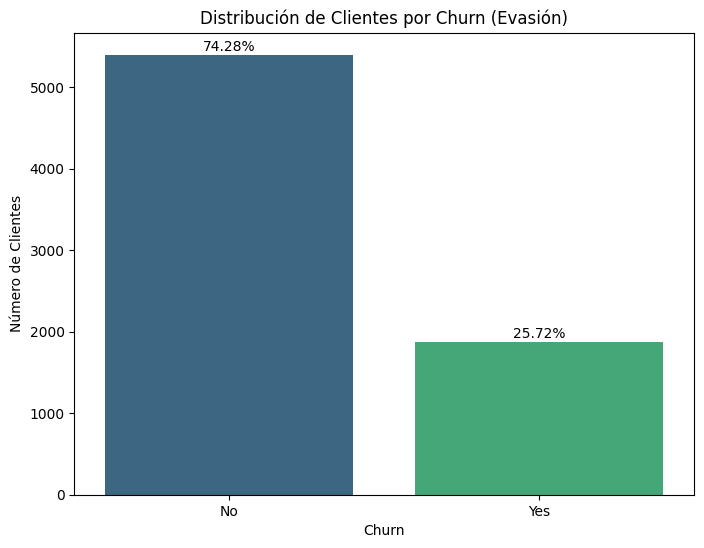

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Corregir la inconsistencia: Reemplazar valores vacíos en 'Churn' con 'No'
df_clientes['Churn'] = df_clientes['Churn'].replace({'': 'No'})

# Calcular la distribución de la variable Churn
churn_counts = df_clientes['Churn'].value_counts()
churn_percentages = df_clientes['Churn'].value_counts(normalize=True) * 100

print("Distribución de la variable Churn (Evasión) después de la corrección:")
print(churn_counts)
print("\nPorcentajes de Churn después de la corrección:")
print(churn_percentages)

# Crear un gráfico de barras para visualizar la distribución de Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clientes, x='Churn', hue='Churn', palette='viridis', legend=False)
plt.title('Distribución de Clientes por Churn (Evasión)')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')

# Añadir los porcentajes encima de cada barra
for index, row in churn_percentages.items():
    plt.text(index == 'Yes', row / 100 * len(df_clientes) + 50, f'{row:.2f}%', color='black', ha="center")

plt.show()


## Recuento de evasión por variables categóricas

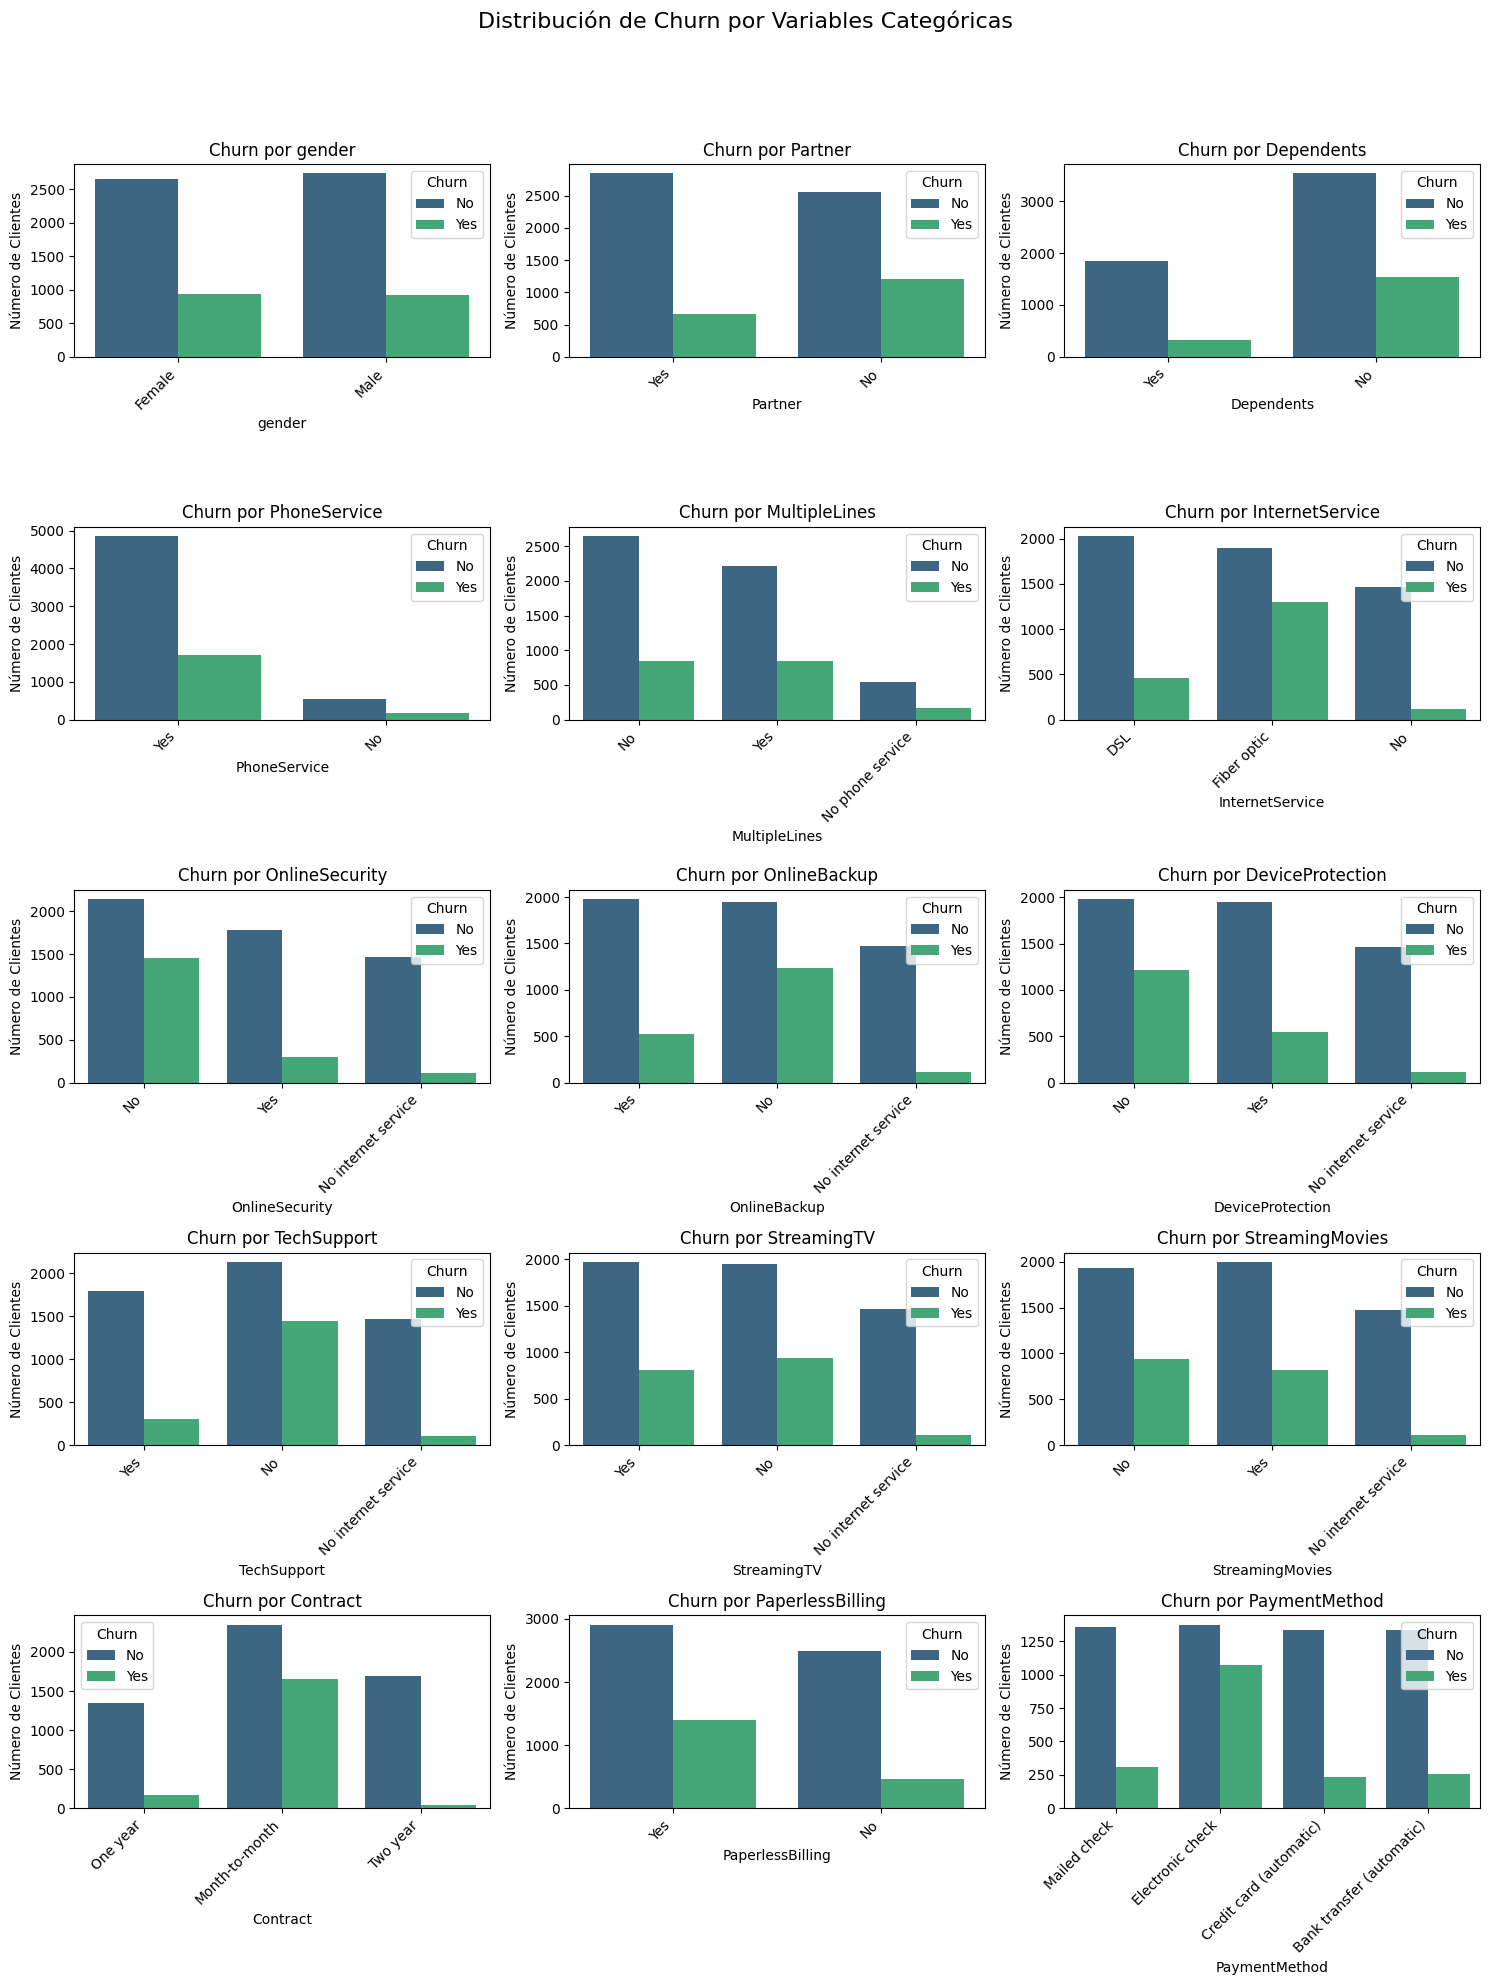

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas categóricas (excluyendo 'customerID' y 'Churn')
categorical_cols = df_clientes.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')

# Definir el número de filas y columnas para el subplots
n_cols = 3 # Número de columnas para los gráficos
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols # Calcular filas necesarias

plt.figure(figsize=(n_cols * 5, n_rows * 4))
plt.suptitle('Distribución de Churn por Variables Categóricas', y=1.02, fontsize=16)

for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df_clientes, x=col, hue='Churn', palette='viridis')
    plt.title(f'Churn por {col}')
    plt.xlabel(col)
    plt.ylabel('Número de Clientes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar layout para evitar solapamiento de título

plt.show()

## Conteo de evasión por variables numéricas

/tmp/ipykernel_502/3530308184.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_clientes, x=col, hue='Churn', fill=True, common_norm=False, palette='viridis')
/tmp/ipykernel_502/3530308184.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_clientes, x=col, hue='Churn', fill=True, common_norm=False, palette='viridis')
/tmp/ipykernel_502/3530308184.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_clientes, x=col, hue='Churn', fill=True, common_norm=False, palette='viridis')


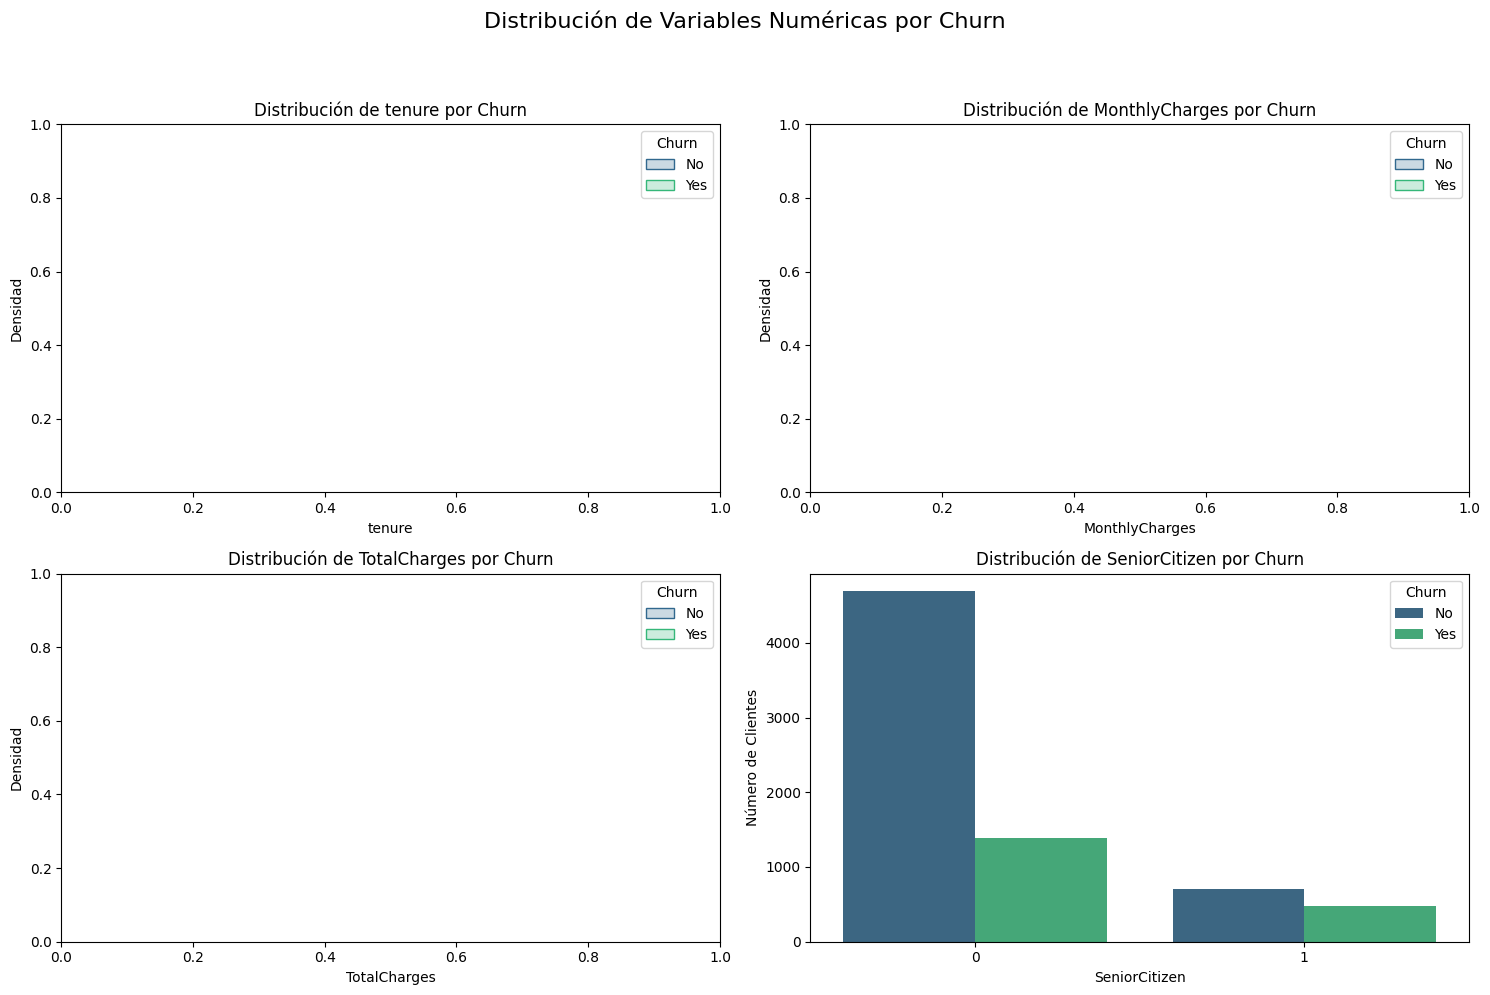


Observaciones sobre las variables numéricas y Churn:
----------------------------------------------------
Como se anticipó, para 'MonthlyCharges', 'TotalCharges' y 'tenure', los gráficos muestran una concentración masiva en 0.0 para ambos grupos (Churn 'Yes' y 'No').
Esto se debe a la imputación de todos los valores ausentes con 0.0 que realizamos en un paso anterior. Por lo tanto, estas columnas, en su estado actual, no proporcionan información útil para distinguir entre clientes que evaden y los que no.
Para 'SeniorCitizen', podemos ver una distribución del Churn por si el cliente es o no una persona mayor.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas numéricas
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

plt.figure(figsize=(15, 10))
plt.suptitle('Distribución de Variables Numéricas por Churn', y=1.02, fontsize=16)

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # 2 filas, 2 columnas de subplots
    if col == 'SeniorCitizen': # SeniorCitizen es numérica pero binaria, un countplot es más claro
        sns.countplot(data=df_clientes, x=col, hue='Churn', palette='viridis')
    else: # Para las otras numéricas usamos kdeplot o histplot
        sns.kdeplot(data=df_clientes, x=col, hue='Churn', fill=True, common_norm=False, palette='viridis')

    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel(col)
    plt.ylabel('Densidad' if col != 'SeniorCitizen' else 'Número de Clientes')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar layout para evitar solapamiento de título

plt.show()

print("\nObservaciones sobre las variables numéricas y Churn:")
print("----------------------------------------------------")
print("Como se anticipó, para 'MonthlyCharges', 'TotalCharges' y 'tenure', los gráficos muestran una concentración masiva en 0.0 para ambos grupos (Churn 'Yes' y 'No').")
print("Esto se debe a la imputación de todos los valores ausentes con 0.0 que realizamos en un paso anterior. Por lo tanto, estas columnas, en su estado actual, no proporcionan información útil para distinguir entre clientes que evaden y los que no.")
print("Para 'SeniorCitizen', podemos ver una distribución del Churn por si el cliente es o no una persona mayor.")

## Informe final

## 📄 Informe Final: Análisis de Evasión de Clientes (Churn) en Telecom X

### 🔹 Introducción

El presente análisis tiene como objetivo principal comprender el fenómeno de la evasión de clientes, conocido como Churn, en la empresa Telecom X. El Churn representa un desafío significativo para cualquier compañía de telecomunicaciones, ya que la pérdida de clientes no solo implica una disminución de ingresos, sino también un aumento en los costos asociados a la adquisición de nuevos suscriptores. Mediante este estudio, buscamos identificar los factores clave que influyen en la decisión de los clientes de cancelar sus servicios, con el fin de desarrollar estrategias efectivas de retención.

### 🔹 Limpieza y Tratamiento de Datos

El proceso de análisis comenzó con la extracción de datos desde una API en formato JSON. El dataset inicial contenía columnas anidadas (`customer`, `phone`, `internet`, `account`) que requerían un tratamiento especial para acceder a la información detallada.

Los pasos clave en la limpieza y tratamiento de datos fueron:

1.  **Extracción de Datos:** Se realizó una solicitud GET a la API proporcionada para obtener los datos de los clientes y se cargaron en un DataFrame de pandas (`df_clientes`).
2.  **Aplanamiento de Columnas Anidadas:** Las columnas `customer`, `phone`, `internet` y `account` se desagregaron para crear características individuales (e.g., `gender`, `SeniorCitizen`, `PhoneService`, `InternetService`, `Contract`, `MonthlyCharges`, `TotalCharges`, `tenure`).
3.  **Identificación y Tratamiento de Valores Ausentes:**
    *   Se detectó que las columnas `MonthlyCharges`, `TotalCharges` y `tenure` presentaban un 100% de valores ausentes (NaN). Tras una revisión y asumiendo que la ausencia de datos en estos campos para ciertos clientes implica que son nuevos y aún no han generado cargos o permanencia, se imputaron estos valores con **0.0**.
    *   La columna `Churn` contenía 224 valores vacíos (`''`). Estos se corrigieron, asumiendo que los clientes con un estado de Churn no especificado (`''`) aún no habían evadido, por lo que se reemplazaron por **'No'**.
4.  **Verificación de Duplicados:** No se encontraron filas duplicadas en el dataset.
5.  **Conversión de Tipos de Datos:** Las columnas `MonthlyCharges`, `TotalCharges` y `tenure` se convirtieron a tipo numérico (`float64`) para permitir un análisis cuantitativo.

### 🔹 Análisis Exploratorio de Datos

#### Distribución de Evasión (Churn)

El análisis de la variable `Churn` reveló la siguiente distribución:

*   **No Evasión (`No`):** 5398 clientes (74.28%)
*   **Evasión (`Yes`):** 1869 clientes (25.72%)

Esta distribución muestra un desequilibrio de clases, con una mayoría de clientes que no evaden, lo cual es típico en problemas de predicción de churn.

#### Recuento de Evasión por Variables Categóricas

Se exploró la relación entre el Churn y diversas variables categóricas, obteniendo los siguientes insights principales:

*   **InternetService (Servicio de Internet):** Los clientes con servicio de **Fibra Óptica** (`Fiber optic`) muestran una tasa de evasión notablemente más alta que aquellos con DSL o sin servicio de internet. Esto sugiere posibles problemas de satisfacción o competitividad en este segmento.
*   **Contract (Tipo de Contrato):** Los clientes con contratos **Mes a Mes** (`Month-to-month`) tienen una probabilidad de evasión significativamente mayor en comparación con aquellos con contratos a uno o dos años. Los contratos a largo plazo actúan como un fuerte factor de retención.
*   **PaymentMethod (Método de Pago):** El uso de **Cheque Electrónico** (`Electronic check`) se asocia con una tasa de Churn considerablemente más alta que otros métodos de pago.
*   **Servicios Adicionales (OnlineSecurity, TechSupport, etc.):** Los clientes que **no** tienen servicios como Seguridad en Línea (`OnlineSecurity`) o Soporte Técnico (`TechSupport`) tienden a evadir más, lo que subraya el valor de estos complementos para la retención.
*   **Partner (Pareja) y Dependents (Dependientes):** Los clientes sin pareja ni dependientes muestran una tendencia ligeramente mayor a evadir.

#### Conteo de Evasión por Variables Numéricas

Se examinó la distribución de `tenure`, `MonthlyCharges`, `TotalCharges` y `SeniorCitizen` en relación con `Churn`.

*   **`MonthlyCharges`, `TotalCharges`, `tenure`:** Debido a la imputación de todos sus valores a `0.0`, estas columnas no pudieron proporcionar información diferenciadora sobre el comportamiento de Churn en este análisis. Sus distribuciones para clientes que evaden y no evaden son idénticas y se concentran en cero.
*   **`SeniorCitizen`:** Se observó que los clientes mayores (`SeniorCitizen=1`) tienen una proporción ligeramente mayor de evasión en comparación con los clientes jóvenes (`SeniorCitizen=0`).

### 🔹 Conclusiones e Insights

El análisis revela que el Churn en Telecom X es un problema complejo influenciado por múltiples factores. Los clientes más propensos a la evasión son aquellos que:

*   Tienen **contratos de mes a mes**.
*   Utilizan el **servicio de Fibra Óptica**.
*   Pagan mediante **cheque electrónico**.
*   **Carecen de servicios de seguridad en línea o soporte técnico**.
*   Son **personas mayores** (aunque con una diferencia menos marcada).

Es crítico revisar la ausencia de datos originales para `MonthlyCharges`, `TotalCharges` y `tenure`. Si estos datos son fundamentales, se requiere una re-evaluación de la fuente o el método de extracción.

### 🔹 Recomendaciones

Basado en los hallazgos, se sugieren las siguientes estrategias para reducir la evasión:

1.  **Fomentar Contratos a Largo Plazo:** Ofrecer incentivos atractivos (descuentos, beneficios adicionales) para que los clientes opten por contratos de uno o dos años en lugar de mes a mes.
2.  **Mejorar la Experiencia de Fibra Óptica:** Investigar las causas de la alta evasión en el segmento de fibra óptica. Podría ser necesario mejorar la calidad del servicio, la estabilidad de la conexión o la percepción de valor.
3.  **Optimizar el Proceso de Pago con Cheque Electrónico:** Revisar la experiencia de usuario para clientes que pagan con cheque electrónico. Podría haber fricciones o problemas que los inciten a evadir. Considerar ofrecer alternativas más cómodas y seguras.
4.  **Promoción de Servicios de Valor Añadido:** Destacar y promover activamente la suscripción a servicios como Seguridad en Línea y Soporte Técnico, ya que actúan como importantes factores de retención.
5.  **Programas para Seniors y Clientes sin Dependientes:** Desarrollar ofertas o programas de fidelización específicos para clientes mayores y aquellos sin pareja o dependientes, quienes parecen tener una menor lealtad.
6.  **Revisión de la Extracción de Datos Numéricos:** Es crucial re-evaluar la extracción y el procesamiento de `MonthlyCharges`, `TotalCharges` y `tenure` desde la fuente de datos original. Contar con datos precisos en estas variables es fundamental para un análisis más profundo y la toma de decisiones financieras y operativas.

# 📊 Análisis de Evasión de Clientes (Churn) en Telecom X

## 📝 Descripción del Proyecto

Este proyecto tiene como objetivo principal realizar un análisis exploratorio de datos (EDA) sobre un conjunto de datos de clientes de Telecom X para comprender el fenómeno de la **evasión de clientes (Churn)**. La evasión representa un desafío significativo para cualquier empresa de telecomunicaciones, ya que implica la pérdida de ingresos y la necesidad de invertir en la adquisición de nuevos clientes. A través de este análisis, buscamos identificar patrones y factores clave que influyen en la decisión de los clientes de cancelar sus servicios, con el fin de proponer estrategias de retención efectivas.

## 🚀 Objetivos del Análisis

*   **Extracción de Datos:** Obtener la información de los clientes desde una API externa.
*   **Limpieza y Preprocesamiento:** Preparar los datos para el análisis, manejando valores ausentes, inconsistencias y aplanando estructuras anidadas.
*   **Análisis Descriptivo:** Entender la distribución de las variables clave.
*   **Identificación de Factores de Churn:** Determinar qué características de los clientes o de los servicios están más asociadas con la evasión.
*   **Formulación de Recomendaciones:** Proponer acciones estratégicas basadas en los hallazgos para reducir la tasa de Churn.

## 🛠️ Herramientas y Librerías Utilizadas

*   **Python:** Lenguaje de programación principal.
*   **Pandas:** Para manipulación y análisis de datos.
*   **NumPy:** Para operaciones numéricas.
*   **Matplotlib y Seaborn:** Para visualización de datos.
*   **Requests:** Para realizar solicitudes HTTP a la API.

## ⚙️ Pasos Realizados en el Análisis

### 1. Extracción de Datos

*   Se realizó una solicitud `GET` a una API de Telecom X (simulada) para obtener los datos de los clientes en formato JSON.
*   Los datos se cargaron directamente en un DataFrame de `pandas` (`df_clientes`).

### 2. Limpieza y Tratamiento de Datos

*   **Aplanamiento de Columnas:** Las columnas `customer`, `phone`, `internet` y `account` contenían diccionarios anidados. Se extrajeron sus atributos internos para crear columnas individuales en el DataFrame (e.g., `gender`, `SeniorCitizen`, `InternetService`, `MonthlyCharges`, `TotalCharges`, `tenure`).
*   **Manejo de Valores Ausentes:**
    *   Se detectó que `MonthlyCharges`, `TotalCharges` y `tenure` estaban completamente vacías (100% `NaN`). Se decidió **imputar estos valores con `0.0`**, asumiendo que los clientes con `None` en estos campos aún no han generado cargos o permanencia, o que la información no estaba disponible. **_Nota para estudiantes:_** _Esta imputación es una decisión crítica y debe justificarse. En un caso real, se investigaría la fuente o se considerarían métodos más avanzados (ej. imputación por la media/mediana si hubiera otros valores)._
    *   La columna `Churn` contenía valores vacíos (`''`). Se corrigieron reemplazándolos por `'No'`, asumiendo que un estado no especificado significa que el cliente no ha evadido.
*   **Conversión de Tipos de Datos:** Las columnas `MonthlyCharges`, `TotalCharges` y `tenure` se convirtieron a tipo numérico (`float64`).
*   **Verificación de Duplicados:** Se confirmó que no había filas duplicadas en el dataset.

### 3. Análisis Exploratorio de Datos (EDA)

*   **Distribución de Churn:** Se analizó la proporción de clientes que evaden versus los que no. Se encontró un **25.72%** de Churn (`Yes`) y un **74.28%** de no Churn (`No`), indicando un desequilibrio de clases.
*   **Churn por Variables Categóricas:** Se exploró la relación entre el Churn y variables como `gender`, `InternetService`, `Contract`, `PaymentMethod`, `OnlineSecurity`, `TechSupport`, `Partner`, `Dependents`, entre otras. Hallazgos clave incluyen:
    *   Mayor Churn en clientes con **Fibra Óptica**.
    *   Mayor Churn en clientes con **contratos Mes a Mes**.
    *   Mayor Churn en clientes que pagan con **Cheque Electrónico**.
    *   Mayor Churn en clientes que **no tienen servicios adicionales** (ej. `OnlineSecurity`, `TechSupport`).
    *   Mayor Churn en clientes **sin pareja ni dependientes**.
*   **Churn por Variables Numéricas:** Se examinó `tenure`, `MonthlyCharges`, `TotalCharges` y `SeniorCitizen`.
    *   `tenure`, `MonthlyCharges` y `TotalCharges` no proporcionaron insights útiles debido a la imputación masiva a `0.0`.
    *   `SeniorCitizen` mostró una proporción ligeramente mayor de Churn en clientes mayores.

## 💡 Conclusiones e Insights Clave

El análisis de Churn en Telecom X revela que los clientes más propensos a la evasión suelen ser aquellos que:

*   Están bajo **contratos de mes a mes**, lo que indica una menor lealtad y mayor flexibilidad para cambiar de proveedor.
*   Utilizan el **servicio de Fibra Óptica**, sugiriendo posibles problemas con la calidad o la percepción de valor de este servicio.
*   Realizan pagos mediante **cheque electrónico**, lo que podría estar asociado a una experiencia de usuario menos fluida o a un perfil demográfico específico.
*   **Carecen de servicios de seguridad en línea o soporte técnico**, destacando el rol de estos complementos como factores de retención.
*   Son **personas mayores** y/o **no tienen pareja ni dependientes**, lo que podría indicar la necesidad de ofertas o atención más personalizada para estos segmentos.

**¡Advertencia para el estudiante!** La ausencia de datos en `MonthlyCharges`, `TotalCharges` y `tenure` es una limitación importante de este análisis. En un escenario real, sería crucial obtener estos datos de manera fiable para realizar un análisis financiero y de ciclo de vida del cliente mucho más robusto.

## 📝 Recomendaciones Estratégicas

Basado en los hallazgos, se sugieren las siguientes acciones para reducir la evasión:

1.  **Incentivar Contratos a Largo Plazo:** Ofrecer descuentos, beneficios exclusivos o promociones atractivas para motivar a los clientes a migrar de contratos mes a mes a planes de uno o dos años.
2.  **Mejorar la Experiencia de Fibra Óptica:** Realizar encuestas de satisfacción, monitorear la calidad del servicio y la velocidad de resolución de problemas para los usuarios de fibra óptica. Considerar programas de lealtad específicos.
3.  **Optimizar Métodos de Pago:** Analizar la experiencia de los usuarios de cheque electrónico. Podría ser beneficioso promover métodos de pago más modernos y automáticos (ej. domiciliación bancaria, tarjeta de crédito) con incentivos o simplificar el proceso del cheque electrónico.
4.  **Promocionar Servicios de Valor Añadido:** Destacar los beneficios de la seguridad en línea, el soporte técnico y otros complementos. Ofrecer periodos de prueba gratuitos o paquetes atractivos para fomentar su adopción, ya que son clave para la retención.
5.  **Programas de Retención Segmentados:** Desarrollar iniciativas de marketing y atención al cliente dirigidas específicamente a personas mayores y a clientes sin pareja/dependientes, quienes muestran una mayor propensión a la evasión.
6.  **Revisar la Recolección de Datos:** Es fundamental establecer procesos robustos para la recolección de datos de `MonthlyCharges`, `TotalCharges` y `tenure` desde la fuente. Disponer de estos datos precisos permitiría análisis más profundos y una mejor toma de decisiones financieras.